# インド株 ファクター検証 — Step 11: 日次 CGO とホライズンのターム構造（1ヶ月〜5年）

Step 9（週次・5点）の拡張。**日次データで直接計算**し、遡及期間を
1m〜13m（1ヶ月刻み）+ 2y / 3y / 5y の **16 点**に増やして CGO のターム構造を見る。

## 週次 → 日次の変更点

| | 週次（Step 8-10） | 日次（本ノート） |
|---|---|---|
| $V_t$ | 週内 turnover 和 | 日次 turnover そのまま |
| $P_{t-1}$ の1期ラグ | 前週末 | **前営業日** |
| 遡及 $N$ | 週数 | **営業日数**（1ヶ月 = 21営業日換算） |

## 計算時間（事前実測）

日次パネル 5,953 営業日 × 1,062 銘柄。構築 2.4 秒、カーネルは N に比例で
5年 4.3 秒 / 12ヶ月 1.2 秒 / 1ヶ月 0.3 秒 → **16ホライズン合計 ~20 秒**。週次と大差なし。

## momentum 中立の定義（本ノート）

短期ホライズンの CGO は直近1ヶ月リターンとも重なるため、
コントロールを **sector + log(Cap) + mom12_1 + mom1** に拡張した
（Step 9 の mn は mom12_1 のみ。表の脚注に明記）。

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 260, "display.max_columns", 40, "display.float_format", lambda v: f"{v:,.3f}")

START, END = 200801, 202607
Q = 5
WEIGHTING = "ew"
FIGDIR = "11_cgo_daily"

MONTHS = list(range(1, 14)) + [24, 36, 60]
HORIZONS = {f"cgo_{m}m": 21 * m for m in MONTHS}   # 1ヶ月 = 21営業日

## 1. 16ホライズン一括計算（日次）

In [2]:
t0 = time.time()
cgo = fl.cgo.monthly_cgo_multi(HORIZONS, start=START, end=END, frequency="daily")
print(f"{time.time()-t0:.1f} 秒  shape={cgo.shape}")

panel = fl.data.build_panel(["mom1", "mom12_1"], start=START, end=END)
for c in HORIZONS:
    panel[c] = cgo[c].reindex(panel.index)
panel = fl.preprocess.standardize_panel(panel, list(HORIZONS) + ["mom1", "mom12_1"], method="blom")

24.1 秒  shape=(170405, 16)


### 日次 vs 週次の突き合わせ（5年）

同じ定義を頻度だけ変えたとき、スコアはどの程度一致するか。

In [3]:
cgo_w = fl.cgo.monthly_cgo_multi({"cgo_5y_w": 260}, start=START, end=END, frequency="weekly")
panel["cgo_5y_w"] = cgo_w["cgo_5y_w"].reindex(panel.index)
panel = fl.preprocess.standardize_panel(panel, "cgo_5y_w", method="blom")
c = fl.multi.cross_sectional_corr(panel, ["cgo_60m_blom", "cgo_5y_w_blom"], labels=["daily", "weekly"])
print("日次5y vs 週次5y の順位相関（月次平均）:", round(float(c.iloc[0, 1]), 4))

日次5y vs 週次5y の順位相関（月次平均）: 0.9834


## 2. momentum 中立スコア（sector + size + mom12_1 + mom1）

In [4]:
for c in HORIZONS:
    panel = fl.preprocess.standardize_panel(
        panel, c, method="blom", group_col="sector",
        control_cols=["log_cap", "mom12_1_blom", "mom1_blom"], suffix="_blom_mn")
print("done")

done


## 3. ターム構造: 分位分析と IC

In [5]:
rows = {}
ics_raw, ics_mn = {}, {}
for m, c in zip(MONTHS, HORIZONS):
    r_raw = fl.quantile.quantile_returns(panel, f"{c}_blom", q=Q, ascending=True)
    r_mn = fl.quantile.quantile_returns(panel, f"{c}_blom_mn", q=Q, ascending=True)
    s_raw = fl.quantile.quantile_summary(r_raw, weighting=WEIGHTING)
    s_mn = fl.quantile.quantile_summary(r_mn, weighting=WEIGHTING)
    ics_raw[c] = fl.ic.information_coefficient(panel, f"{c}_blom", "fwd_rtn")
    ics_mn[c] = fl.ic.information_coefficient(panel, f"{c}_blom_mn", "fwd_rtn")
    i_raw, i_mn = fl.ic.ic_summary(ics_raw[c]), fl.ic.ic_summary(ics_mn[c])
    spread = f"Q{Q}-Q1"
    rows[m] = {
        ("raw", "ls_ann_excess"): s_raw.loc[spread, "ann_excess"],
        ("raw", "ls_t_NW"): s_raw.loc[spread, "t_stat_NW"],
        ("raw", "top_ann_excess"): s_raw.loc[f"Q{Q}", "ann_excess"],
        ("raw", "top_t_NW"): s_raw.loc[f"Q{Q}", "t_stat_NW"],
        ("raw", "mean_IC"): i_raw["mean_IC"],
        ("raw", "IC_t_NW"): i_raw["t_stat_NW"],
        ("raw", "ls_turnover_ann"): s_raw.loc[spread, "turnover_ann"],
        ("mn", "ls_ann_excess"): s_mn.loc[spread, "ann_excess"],
        ("mn", "ls_t_NW"): s_mn.loc[spread, "t_stat_NW"],
        ("mn", "top_ann_excess"): s_mn.loc[f"Q{Q}", "ann_excess"],
        ("mn", "top_t_NW"): s_mn.loc[f"Q{Q}", "t_stat_NW"],
        ("mn", "mean_IC"): i_mn["mean_IC"],
        ("mn", "IC_t_NW"): i_mn["t_stat_NW"],
    }

ts = pd.DataFrame(rows).T
ts.index.name = "months"
ts

raw                                                                            mn                                                
       ls_ann_excess ls_t_NW top_ann_excess top_t_NW mean_IC IC_t_NW ls_turnover_ann ls_ann_excess ls_t_NW top_ann_excess top_t_NW mean_IC IC_t_NW
months                                                                                                                                            
1             -0.014  -0.019         -0.018   -0.591  -0.002  -0.258          19.039        -0.003   0.050         -0.013   -0.051   0.003   0.718
2             -0.003   0.381         -0.006   -0.131   0.004   0.497          16.303         0.009   0.663         -0.020   -0.285   0.003   0.651
3              0.034   1.535          0.014    0.716   0.015   1.660          13.826         0.023   1.335         -0.011    0.082   0.008   1.548
4              0.061   2.242          0.037    1.714   0.024   2.483          12.225         0.042   2.109          0.006    0.694   0.011   1.865
5              0.061   2.053          0.043    2.016   0.029   3.006          11.204         0.045   2.067          0.010    0.849   0.012   2.005
6              0.074   2.281          0.052    2.425   0.034   3.403          10.384         0.041   1.884          0.010    0.866   0.013   2.048
7              0.097   2.697          0.061    2.755   0.038   3.720           9.700         0.043   1.917         -0.002    0.422   0.014   2.073
8              0.097   2.567          0.058    2.524   0.042   4.015           9.235         0.058   2.488          0.008    0.802   0.015   2.229
9              0.091   2.458          0.059    2.522   0.044   4.216           8.855         0.061   2.699          0.011    0.929   0.017   2.516
10             0.098   2.507          0.071    2.994   0.046   4.360           8.521         0.063   2.761          0.010    0.874   0.018   2.663
11             0.098   2.493          0.070    2.918   0.049   4.522           8.212         0.062   2.720          0.009    0.822   0.019   2.919
12             0.102   2.589          0.071    2.942   0.050   4.614           7.935         0.073   3.022          0.021    1.263   0.021   3.120
13             0.105   2.658          0.072    2.955   0.052   4.682           7.689         0.077   3.204          0.027    1.514   0.022   3.370
24             0.093   2.266          0.077    3.035   0.053   4.434           6.358         0.049   2.468          0.028    1.499   0.026   4.084
36             0.076   1.959          0.072    2.727   0.053   4.202           5.756         0.045   2.082          0.030    1.527   0.027   4.067
60             0.081   2.111          0.080    3.035   0.054   4.211           5.146         0.057   2.444          0.047    2.047   0.033   4.661

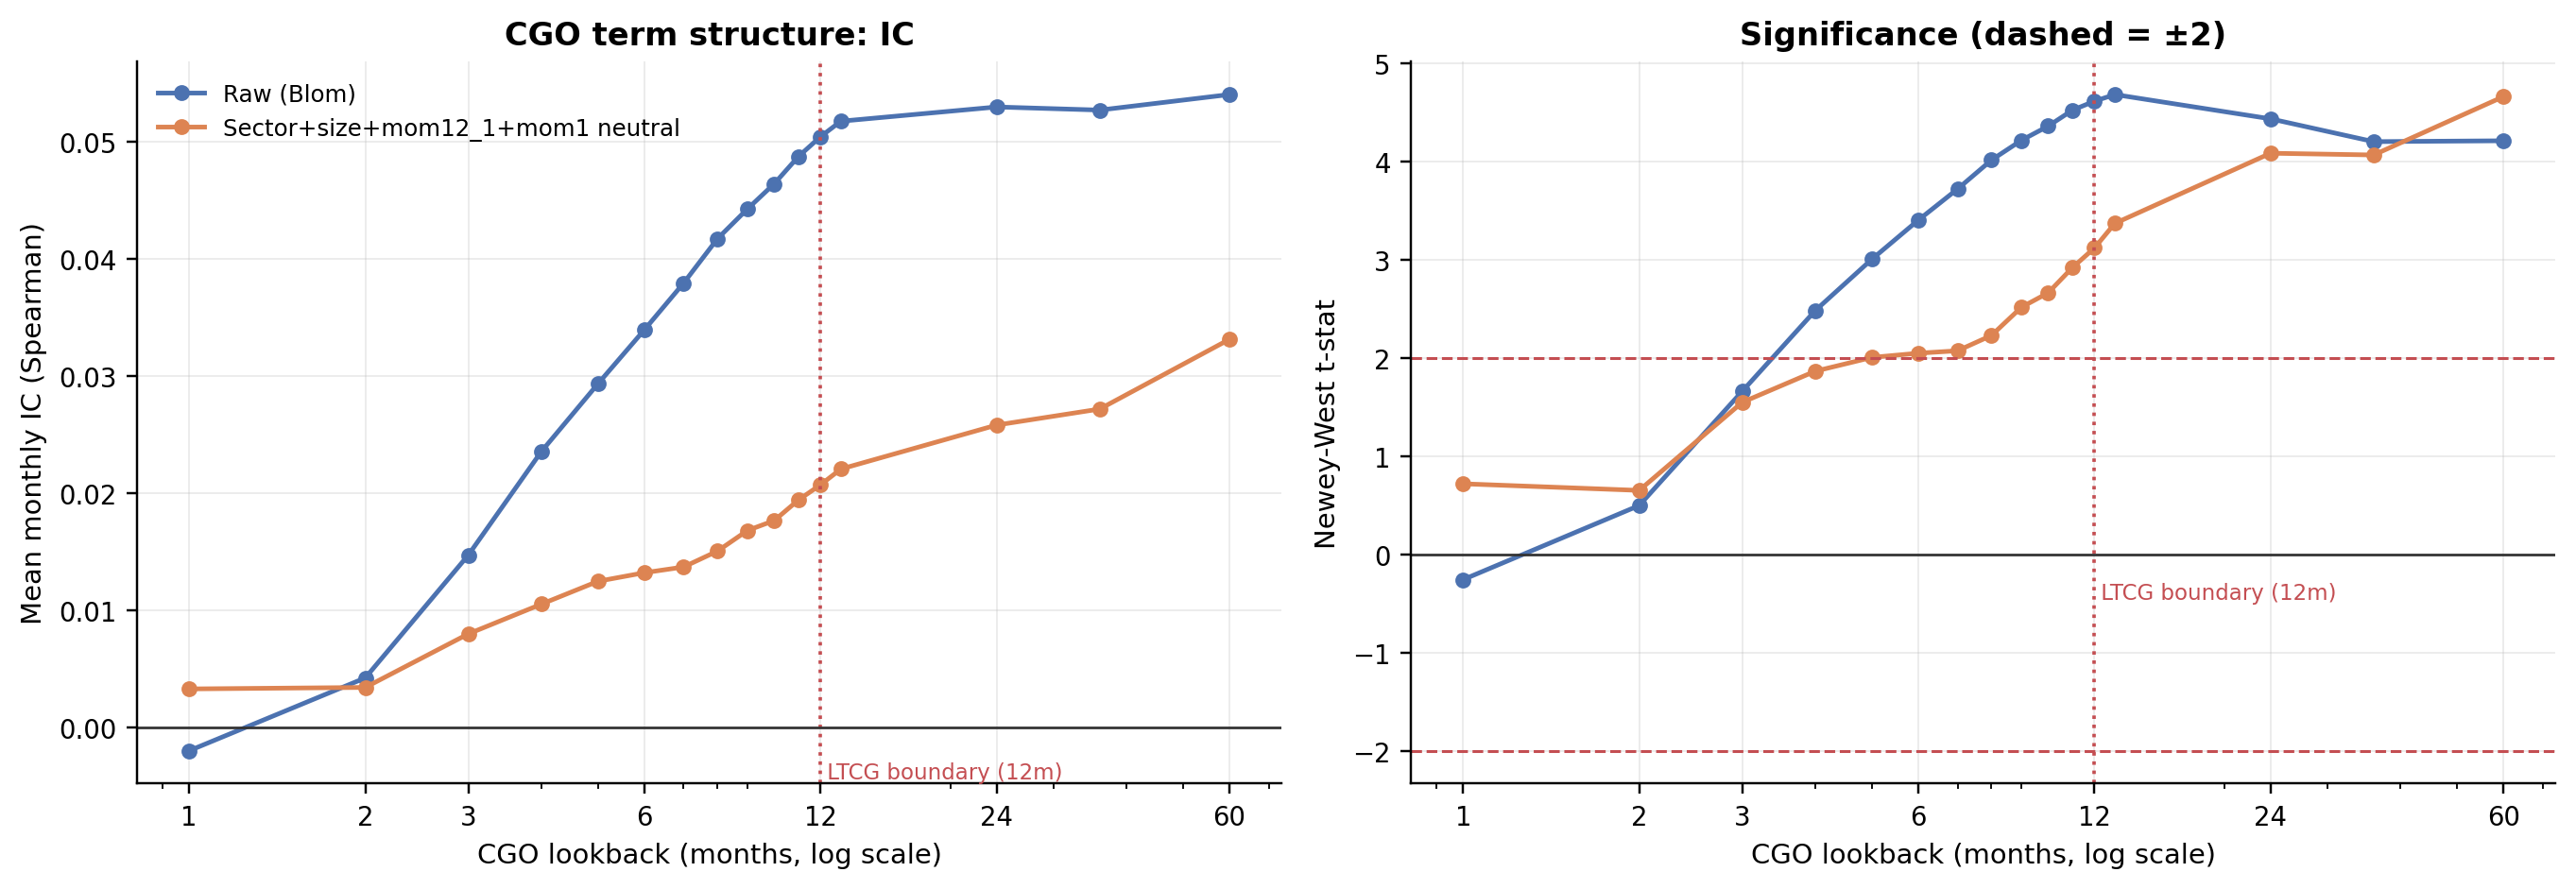

In [6]:
def term_plot(metric, tcol, ylabel, title, is_pct, fname):
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
    for var, color, label in [("raw", "#4C72B0", "Raw (Blom)"),
                              ("mn", "#DD8452", "Sector+size+mom12_1+mom1 neutral")]:
        axes[0].plot(ts.index, ts[(var, metric)], marker="o", markersize=4.5,
                     color=color, linewidth=1.6, label=label)
        axes[1].plot(ts.index, ts[(var, tcol)], marker="o", markersize=4.5,
                     color=color, linewidth=1.6, label=label)
    for ax in axes:
        ax.set_xscale("log")
        ax.set_xticks([1, 2, 3, 6, 12, 24, 60])
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        ax.axvline(12, color="#C44E52", linestyle=":", linewidth=1.2)
        ax.text(12, ax.get_ylim()[0], " LTCG boundary (12m)", fontsize=7.5,
                color="#C44E52", va="bottom")
        ax.set_xlabel("CGO lookback (months, log scale)")
        ax.axhline(0, color="#333333", linewidth=0.9)
    axes[0].set_ylabel(ylabel)
    axes[0].set_title(title)
    axes[0].legend(fontsize=8)
    if is_pct:
        axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.0f}%"))
    for y in (2, -2):
        axes[1].axhline(y, color="#C44E52", linestyle="--", linewidth=1.0)
    axes[1].set_ylabel("Newey-West t-stat")
    axes[1].set_title("Significance (dashed = ±2)")
    fig.tight_layout()
    fl.plotting.savefig(fig, f"{FIGDIR}/{fname}")
    return fig


term_plot("mean_IC", "IC_t_NW", "Mean monthly IC (Spearman)",
          "CGO term structure: IC", False, "90_term_ic");

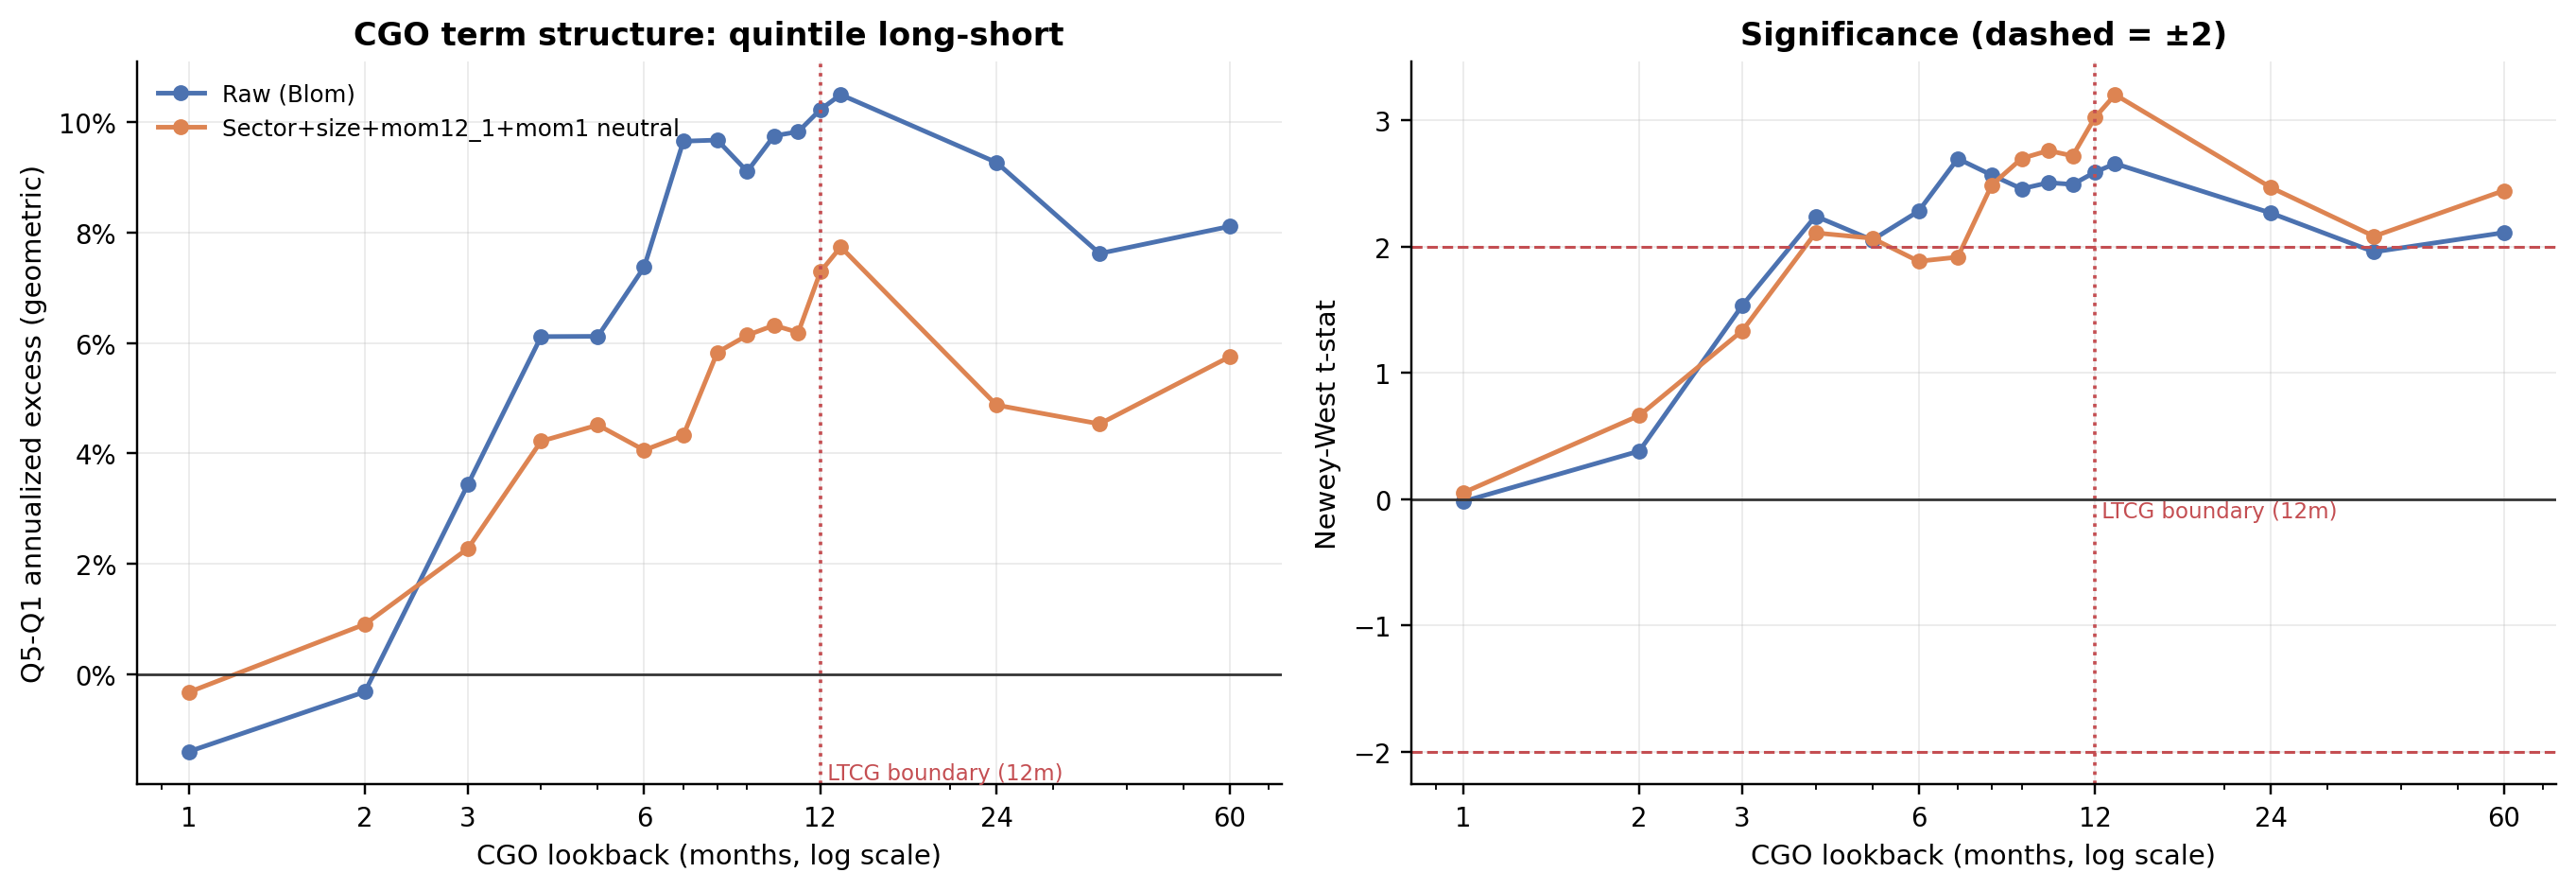

In [7]:
term_plot("ls_ann_excess", "ls_t_NW", "Q5-Q1 annualized excess (geometric)",
          "CGO term structure: quintile long-short", True, "91_term_ls");

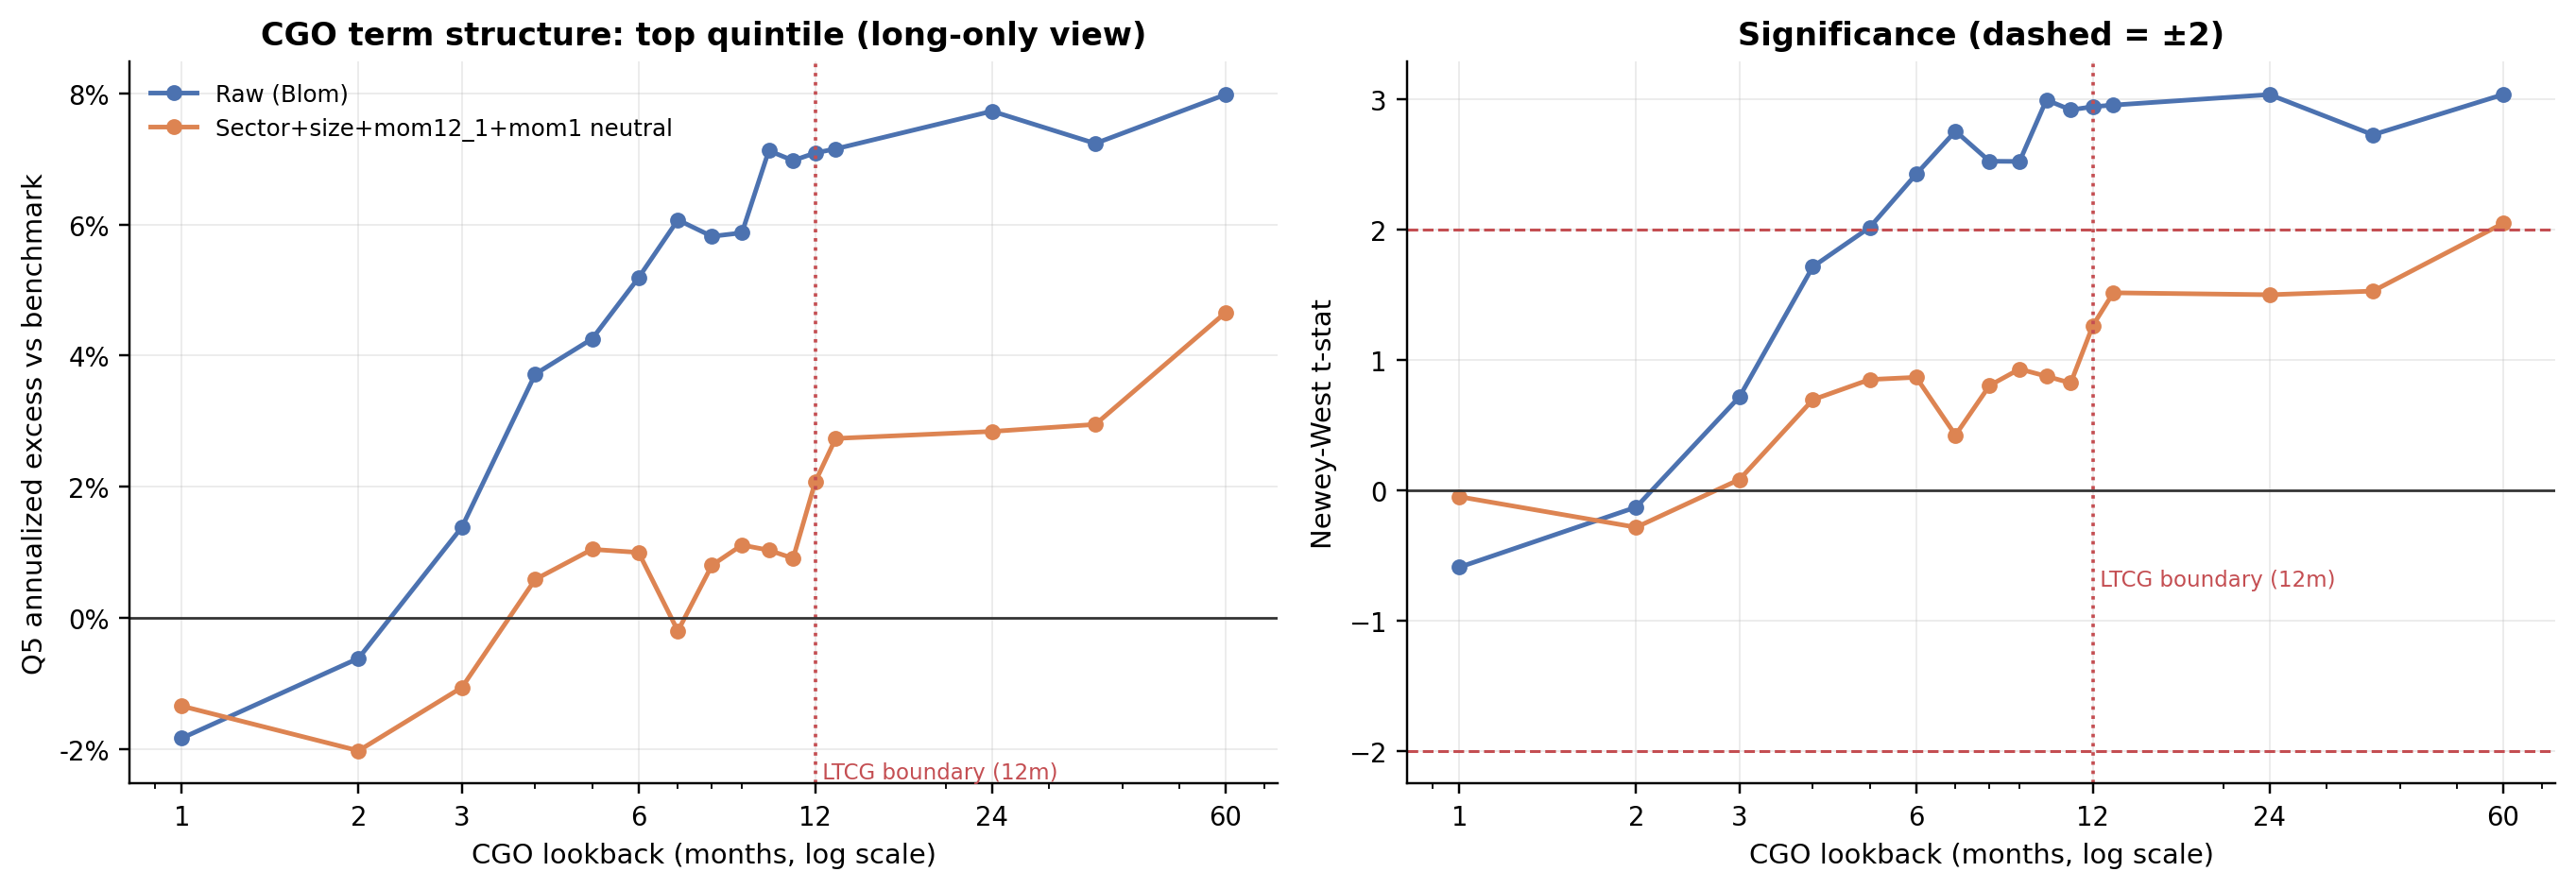

In [8]:
term_plot("top_ann_excess", "top_t_NW", "Q5 annualized excess vs benchmark",
          "CGO term structure: top quintile (long-only view)", True, "92_term_top");

## 4. 隣接ホライズン間の相関（どこで情報が変わるか）

In [9]:
cols = [f"{c}_blom" for c in HORIZONS]
labs = [f"{m}m" for m in MONTHS]
corr = fl.multi.cross_sectional_corr(panel, cols, labels=labs)
adj = pd.Series({f"{labs[i]}->{labs[i+1]}": corr.iloc[i, i+1] for i in range(len(labs)-1)})
print("隣接ホライズンの順位相関:")
print(adj.round(3).to_string())
print("\n12m 近辺: corr(11m,12m) =", round(corr.loc['11m','12m'],3),
      " corr(12m,13m) =", round(corr.loc['12m','13m'],3),
      " corr(1m,60m) =", round(corr.loc['1m','60m'],3))

隣接ホライズンの順位相関:
1m->2m     0.851
2m->3m     0.936
3m->4m     0.964
4m->5m     0.977
5m->6m     0.985
6m->7m     0.988
7m->8m     0.991
8m->9m     0.993
9m->10m    0.994
10m->11m   0.995
11m->12m   0.996
12m->13m   0.996
13m->24m   0.923
24m->36m   0.968
36m->60m   0.966

12m 近辺: corr(11m,12m) = 0.996  corr(12m,13m) = 0.996  corr(1m,60m) = 0.323


---

## 読みどころ

1. **IC・Q5 のターム構造**: どの保有年限の含み損益が予測力を持つか。
   mom1 まで落とした mn 線が「純粋な overhang 情報」
2. **12ヶ月境界**（赤点線）の前後で構造が変わるか
3. 隣接相関が最も低い場所 = 情報の入れ替わりが速いホライズン帯
4. 日次 vs 週次（5年）の順位相関 — 頻度の選択がどれだけ効くか